# MathQuest — Placement Model (Pre-Test)
## Menentukan Topik Lemah Siswa Berdasarkan Hasil Pre-Test

---

### Format Data dalam Pipeline ini:

| Tahap | Format |
|-------|--------|
| **Input dari Backend** | `user_id, no_soal, materi, benar_salah, waktu_pengerjaan` |
| **Setelah diproses model** | `user_id, materi, akurasi_per_materi, avg_waktu_per_materi` |
| **Output ke Backend** | `user_id, weak_topics, confidence` |

### Target Performa:
- Akurasi minimal **85%**
- MAE maksimal **0.02**

In [1]:
!pip install tensorflow numpy pandas scikit-learn joblib matplotlib

  Using cached tensorflow-2.21.0-cp310-cp310-win_amd64.whl (350.6 MB)
  Using cached protobuf-7.35.0-cp310-abi3-win_amd64.whl (439 kB)
  Using cached keras-3.12.2-py3-none-any.whl (1.5 MB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-intel 2.18.0 requires ml-dtypes<0.5.0,>=0.4.0, but you have ml-dtypes 0.5.4 which is incompatible.
tensorflow-intel 2.18.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.3, but you have protobuf 7.35.0 which is incompatible.
tensorflow-intel 2.18.0 requires tensorboard<2.19,>=2.18, but you have tensorboard 2.20.0 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.35.0 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.35.0 which is incompatible.

[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import joblib

import json

import tensorflow as tf

from tensorflow import keras

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import mean_absolute_error

from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow versi:", tf.__version__, keras.__version__)

c:\Users\Acer\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


TensorFlow versi: 2.21.0 3.12.2


## Step 3 — Konfigurasi

In [3]:
LABEL_MAP = {
    0: "pemula", 
    1: "menengah",
    2: "mahir",
}

THRESHOLD_WEAK = 0.6

MAX_WEAK_TOPICS = 3

BATAS_PEMULA   = 0.30  
BATAS_MENENGAH = 0.50

# ── Path file format .keras (format utama) ────────────────────────────────────
# Dipakai saat load di Python/FastAPI
MODEL_PATH    = "saved_model/placement_model.keras"
SCALER_PATH   = "saved_model/placement_scaler.pkl"
FEATURES_PATH = "saved_model/feature_names.txt"

# ── Path file format .json (format tambahan) ──────────────────────────────────
# Dipakai kalau dibutuhkan format JSON untuk keperluan lain
# Model JSON = arsitektur model saja (tanpa bobot)
# Model Weights = bobot model saja (file terpisah)
MODEL_JSON_PATH     = "saved_model/placement_model_architecture.json"
MODEL_WEIGHTS_PATH  = "saved_model/placement_model_weights.weights.h5"

# ── Path file metadata (tambahan) ─────────────────────────────────────────────
# Menyimpan info konfigurasi model dalam format JSON
# Berguna untuk dokumentasi dan keperluan integrasi
MODEL_META_PATH = "saved_model/placement_model_metadata.json"

os.makedirs("saved_model",      exist_ok=True)
os.makedirs("tensorboard_logs", exist_ok=True)

print("Konfigurasi selesai OK")
print(f"  Threshold weak topic : akurasi < {THRESHOLD_WEAK}")
print(f"  Maks weak topics     : {MAX_WEAK_TOPICS}")
print(f"  Batas pemula         : akurasi < {BATAS_PEMULA}")
print(f"  Batas menengah       : akurasi {BATAS_PEMULA} - {BATAS_MENENGAH}")
print(f"  Batas mahir          : akurasi > {BATAS_MENENGAH}")
print()
print("Path file:")
print(f"  [.keras]   {MODEL_PATH}")
print(f"  [.pkl]     {SCALER_PATH}")
print(f"  [.txt]     {FEATURES_PATH}")
print(f"  [.json]    {MODEL_JSON_PATH}")
print(f"  [.h5]      {MODEL_WEIGHTS_PATH}")
print(f"  [.json]    {MODEL_META_PATH}")


Konfigurasi selesai OK
  Threshold weak topic : akurasi < 0.6
  Maks weak topics     : 3
  Batas pemula         : akurasi < 0.3
  Batas menengah       : akurasi 0.3 - 0.5
  Batas mahir          : akurasi > 0.5

Path file:
  [.keras]   saved_model/placement_model.keras
  [.pkl]     saved_model/placement_scaler.pkl
  [.txt]     saved_model/feature_names.txt
  [.json]    saved_model/placement_model_architecture.json
  [.h5]      saved_model/placement_model_weights.weights.h5
  [.json]    saved_model/placement_model_metadata.json



### Custom Layer: TopicAttentionLayer

In [4]:
class TopicAttentionLayer(keras.layers.Layer):

    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)

        self.units = units

        self.attention_dense = keras.layers.Dense(units, activation="sigmoid")

    def call(self, inputs):
        attention_weights = self.attention_dense(inputs)

        return inputs * attention_weights

    def get_config(self):
        config = super().get_config()
        config.update({"units": self.units})
        return config

### Custom Loss: WeightedCrossEntropyLoss

In [5]:
class WeightedCrossEntropyLoss(keras.losses.Loss):

    def __init__(self, class_weights=None, name="weighted_cross_entropy", **kwargs):
        super().__init__(name=name, **kwargs)

        self.class_weights_list = class_weights if class_weights else [3.0, 1.0, 1.0]

        self.class_weights_tensor = tf.constant(
            self.class_weights_list, dtype=tf.float32
        )

    def call(self, y_true, y_pred):
        ce_loss = keras.losses.sparse_categorical_crossentropy(
            y_true, y_pred, from_logits=False
        )

        y_true_int = tf.cast(y_true, tf.int32)

        sample_weights = tf.gather(self.class_weights_tensor, y_true_int)

        weighted_loss = ce_loss * sample_weights

        return tf.reduce_mean(weighted_loss)

    def get_config(self):
        config = super().get_config()
        config.update({"class_weights": self.class_weights_list})
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

### Custom Callback: TrainingLogger

In [6]:
class TrainingLogger(keras.callbacks.Callback):

    def __init__(self, log_path="saved_model/training_log.csv"):
        super().__init__()
        self.log_path = log_path
        self.logs_history = []

    def on_epoch_end(self, epoch, logs=None):
        entry = {
            "epoch"        : epoch + 1,
            "loss"         : round(logs.get("loss",         0), 4),
            "accuracy"     : round(logs.get("accuracy",     0), 4),
            "val_loss"     : round(logs.get("val_loss",     0), 4),
            "val_accuracy" : round(logs.get("val_accuracy", 0), 4),
        }

        self.logs_history.append(entry)

        pd.DataFrame(self.logs_history).to_csv(self.log_path, index=False)

Di cell ini ada **3 pilihan** cara memasukkan data:
- **Opsi A:** Pakai file **CSV**
- **Opsi B:** Pakai file **JSON**
- **Opsi C:** Pakai **data dummy** (sementara, sebelum data nyata tersedia)

### Format Data:
| Kolom | Tipe | Keterangan |
|-------|------|------------|
| `user_id` | string | ID unik siswa |
| `no_soal` | integer | Nomor urut soal |
| `materi` | string | Nama materi/topik soal |
| `benar_salah` | integer | 1 = benar, 0 = salah |
| `waktu_pengerjaan` | float | Waktu dalam detik |


### Opsi A — Load dari CSV

In [7]:
# CSV_PATH = "data/pretest_data.csv"

# df = pd.read_csv(CSV_PATH)

# print(f"Jumlah baris  : {df.shape[0]:,}")
# print(f"Jumlah kolom  : {df.shape[1]}")
# print(f"Nama kolom    : {df.columns.tolist()}")
# print(f"Jumlah siswa  : {df['user_id'].nunique()}")
# print(f"Daftar materi : {sorted(df['materi'].unique())}")
# print()
# print("5 baris pertama:")
# df.head()

### Opsi B — Load dari JSON

In [8]:
# JSON_PATH = "data/pretest_data.json"

# with open(JSON_PATH, "r") as f:
#     data = json.load(f)   # ubah JSON string menjadi list of dict

# df = pd.DataFrame(data)

# print(f"Jumlah baris  : {df.shape[0]:,}")
# print(f"Jumlah kolom  : {df.shape[1]}")
# print(f"Nama kolom    : {df.columns.tolist()}")
# print(f"Jumlah siswa  : {df['user_id'].nunique()}")
# print(f"Daftar materi : {sorted(df['materi'].unique())}")
# print()
# print("5 baris pertama:")
# df.head()

### Opsi C — Data Dummy (Sementara)

In [ ]:
def generate_dummy(n_students=1800, seed=42):
    daftar_materi = [
        "penjumlahan", "pengurangan", "perkalian", "pembagian",
        "pecahan", "aljabar", "geometri", "statistika",
        "peluang", "trigonometri"
    ]

    np.random.seed(seed) 
    rows = [] 

    for i in range(n_students):
        user_id = f"stu_{i+1:04d}"

        kemampuan = np.random.uniform(0.1, 0.9)

        n_soal = np.random.randint(15, 26)

        for no_soal in range(1, n_soal + 1):
            materi = np.random.choice(daftar_materi)

            prob_benar = np.clip(
                kemampuan + np.random.normal(0, 0.15),
                0.05, 0.95
            )

            benar_salah = int(np.random.random() < prob_benar)

            base_waktu = 30 - (kemampuan * 20)
            waktu = max(2.0, base_waktu + np.random.normal(0, 5))

            rows.append({
                "user_id"          : user_id,
                "no_soal"          : no_soal,
                "materi"           : materi,
                "benar_salah"      : benar_salah,
                "waktu_pengerjaan" : round(waktu, 1),
            })

    return pd.DataFrame(rows)

df = generate_dummy(n_students=1800, seed=42)

print(f"Dataset dummy berhasil dibuat ✓")
print(f"Jumlah baris  : {df.shape[0]:,}")
print(f"Jumlah siswa  : {df['user_id'].nunique()}")
print(f"Daftar materi : {sorted(df['materi'].unique())}")
print()
print("5 baris pertama (format yang dikirim backend):")
df.head(10)

Dataset dummy berhasil dibuat ✓
Jumlah baris  : 35,901
Jumlah siswa  : 1800
Daftar materi : ['aljabar', 'geometri', 'pecahan', 'peluang', 'pembagian', 'pengurangan', 'penjumlahan', 'perkalian', 'statistika', 'trigonometri']

5 baris pertama (format yang dikirim backend):


,user_id,no_soal,materi,benar_salah,waktu_pengerjaan
0,stu_0001,1,statistika,1,23.6
1,stu_0001,2,statistika,0,19.9
2,stu_0001,3,pecahan,1,19.4
3,stu_0001,4,trigonometri,0,26.8
4,stu_0001,5,trigonometri,0,21.2
5,stu_0001,6,geometri,0,23.8
6,stu_0001,7,geometri,1,26.7
7,stu_0001,8,pembagian,0,16.5
8,stu_0001,9,statistika,1,15.9
9,stu_0001,10,aljabar,1,15.0


In [10]:
os.makedirs("data", exist_ok=True)

contoh_csv = pd.DataFrame([
    {"user_id": "stu_0001", "no_soal": 1, "materi": "penjumlahan",  "benar_salah": 1, "waktu_pengerjaan": 12.5},
    {"user_id": "stu_0001", "no_soal": 2, "materi": "pengurangan",  "benar_salah": 0, "waktu_pengerjaan": 34.2},
    {"user_id": "stu_0001", "no_soal": 3, "materi": "perkalian",    "benar_salah": 1, "waktu_pengerjaan": 18.7},
    {"user_id": "stu_0001", "no_soal": 4, "materi": "penjumlahan",  "benar_salah": 0, "waktu_pengerjaan": 45.1},
    {"user_id": "stu_0001", "no_soal": 5, "materi": "pecahan",      "benar_salah": 0, "waktu_pengerjaan": 52.3},
    {"user_id": "stu_0002", "no_soal": 1, "materi": "penjumlahan",  "benar_salah": 1, "waktu_pengerjaan": 8.2},
    {"user_id": "stu_0002", "no_soal": 2, "materi": "pengurangan",  "benar_salah": 1, "waktu_pengerjaan": 9.5},
    {"user_id": "stu_0002", "no_soal": 3, "materi": "perkalian",    "benar_salah": 1, "waktu_pengerjaan": 11.3},
])

contoh_csv.to_csv("data/contoh_pretest.csv", index=False)
print("File contoh CSV disimpan → data/contoh_pretest.csv")

contoh_json = contoh_csv.to_dict(orient="records")

with open("data/contoh_pretest.json", "w") as f:
    json.dump(contoh_json, f, indent=2)
print("File contoh JSON disimpan → data/contoh_pretest.json")

print()
print("Referensi format data untuk backend:")
print()
print("Preview isi JSON:")
print(json.dumps(contoh_json[:3], indent=2))

File contoh CSV disimpan → data/contoh_pretest.csv
File contoh JSON disimpan → data/contoh_pretest.json

Referensi format data untuk backend:

Preview isi JSON:
[
  {
    "user_id": "stu_0001",
    "no_soal": 1,
    "materi": "penjumlahan",
    "benar_salah": 1,
    "waktu_pengerjaan": 12.5
  },
  {
    "user_id": "stu_0001",
    "no_soal": 2,
    "materi": "pengurangan",
    "benar_salah": 0,
    "waktu_pengerjaan": 34.2
  },
  {
    "user_id": "stu_0001",
    "no_soal": 3,
    "materi": "perkalian",
    "benar_salah": 1,
    "waktu_pengerjaan": 18.7
  }
]


In [ ]:
def preprocess(df):
    kolom_wajib = ["user_id", "no_soal", "materi", "benar_salah", "waktu_pengerjaan"]
    for kolom in kolom_wajib:
        if kolom not in df.columns:
            raise ValueError(f"Kolom '{kolom}' tidak ditemukan! "
                           f"Kolom yang ada: {df.columns.tolist()}")
    print(f"Kolom valid: {kolom_wajib}")

    n_awal = len(df)

    df = df.dropna(subset=["benar_salah", "waktu_pengerjaan", "materi"])

    df = df[df["waktu_pengerjaan"].between(1, 300)]

    df = df[df["benar_salah"].isin([0, 1])]

    n_bersih = len(df)
    print(f"Cleaning: {n_awal:,} baris → {n_bersih:,} baris "
          f"({n_awal - n_bersih} baris dihapus)")

    akurasi_per_materi = (
        df.groupby(["user_id", "materi"])["benar_salah"]
        .mean()
        .unstack(fill_value=0)
    )

    akurasi_per_materi.columns = [
        f"akurasi_{m}" for m in akurasi_per_materi.columns
    ]

    avg_waktu_per_materi = (
        df.groupby(["user_id", "materi"])["waktu_pengerjaan"]
        .mean()
        .unstack(fill_value=0)
    )

    avg_waktu_per_materi.columns = [
        f"avg_waktu_{m}" for m in avg_waktu_per_materi.columns
    ]

    df_per_siswa = akurasi_per_materi.merge(
        avg_waktu_per_materi,
        on="user_id",
        how="inner"
    )

    print(f"Fitur per siswa: {df_per_siswa.shape[1]} kolom fitur")
    print(f"Jumlah siswa   : {df_per_siswa.shape[0]}")

    feat_names = df_per_siswa.columns.tolist()

    kolom_akurasi = [k for k in feat_names if k.startswith("akurasi_")]
    akurasi_overall = df_per_siswa[kolom_akurasi].mean(axis=1)

    def tentukan_label(akurasi):
        if akurasi < BATAS_PEMULA:
            return 0 
        elif akurasi < BATAS_MENENGAH:
            return 1
        else:
            return 2 

    y = akurasi_overall.apply(tentukan_label).values

    user_ids = df_per_siswa.index.tolist() 

    X = df_per_siswa.values

    scaler = MinMaxScaler() 
    X_scaled = scaler.fit_transform(X) 

    unique, counts = np.unique(y, return_counts=True)
    print(f"\n  Distribusi label:")
    for u, c in zip(unique, counts):
        bar = "█" * int(c / len(y) * 30)
        print(f"    Kelas {u} ({LABEL_MAP[u]:>8}): "
              f"{c:>4} siswa ({c/len(y)*100:.1f}%) {bar}")

    print(f"\nPreprocessing selesai ✓")
    return X_scaled, y, scaler, feat_names, user_ids

X, y, scaler, feat_names, user_ids = preprocess(df)

print(f"\nRingkasan hasil preprocessing:")
print(f"  Jumlah fitur  : {X.shape[1]}")
print(f"  Jumlah siswa  : {X.shape[0]}")
print(f"  Nama fitur    :")
for nama in feat_names:
    print(f"    - {nama}")

  ✓ Kolom valid: ['user_id', 'no_soal', 'materi', 'benar_salah', 'waktu_pengerjaan']
  ✓ Cleaning: 35,901 baris → 35,901 baris (0 baris dihapus)
Fitur per siswa: 20 kolom fitur
Jumlah siswa   : 1800

  Distribusi label:
    Kelas 0 (  pemula):  543 siswa (30.2%) █████████
    Kelas 1 (menengah):  495 siswa (27.5%) ████████
    Kelas 2 (   mahir):  762 siswa (42.3%) ████████████

Preprocessing selesai ✓

Ringkasan hasil preprocessing:
  Jumlah fitur  : 20
  Jumlah siswa  : 1800
  Nama fitur    :
    - akurasi_aljabar
    - akurasi_geometri
    - akurasi_pecahan
    - akurasi_peluang
    - akurasi_pembagian
    - akurasi_pengurangan
    - akurasi_penjumlahan
    - akurasi_perkalian
    - akurasi_statistika
    - akurasi_trigonometri
    - avg_waktu_aljabar
    - avg_waktu_geometri
    - avg_waktu_pecahan
    - avg_waktu_peluang
    - avg_waktu_pembagian
    - avg_waktu_pengurangan
    - avg_waktu_penjumlahan
    - avg_waktu_perkalian
    - avg_waktu_statistika
    - avg_waktu_trigonometr

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y   
)

print(f"Training set : {X_train.shape[0]} siswa ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set     : {X_test.shape[0]} siswa ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"Jumlah fitur : {X_train.shape[1]}")

Training set : 1440 siswa (80%)
Test set     : 360 siswa (20%)
Jumlah fitur : 20


## Step 9 — Bangun Arsitektur Model

In [13]:
def build_placement_model(input_dim, num_classes=3):
    inputs = keras.Input(shape=(input_dim,), name="fitur_siswa")

    x = TopicAttentionLayer(units=input_dim, name="topic_attention")(inputs)

    x = keras.layers.Dense(128, activation="relu", name="dense_1")(x)
    x = keras.layers.BatchNormalization(name="bn_1")(x)
    x = keras.layers.Dropout(0.3, name="dropout_1")(x)

    x = keras.layers.Dense(64, activation="relu", name="dense_2")(x)
    x = keras.layers.BatchNormalization(name="bn_2")(x)
    x = keras.layers.Dropout(0.3, name="dropout_2")(x)

    x = keras.layers.Dense(32, activation="relu", name="dense_3")(x)

    outputs = keras.layers.Dense(
        num_classes, activation="softmax", name="output"
    )(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="PlacementModel")
    return model


input_dim = X_train.shape[1] 
model     = build_placement_model(input_dim=input_dim)

model.summary()

Model: "PlacementModel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fitur_siswa (InputLayer)        │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ topic_attention                 │ (None, 20)             │           420 │
│ (TopicAttentionLayer)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,311 (55.90 KB)

 Trainable params: 13,927 (54.40 KB)

 Non-trainable params: 384 (1.50 KB)

In [14]:
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=0.001),
    loss      = WeightedCrossEntropyLoss(class_weights=[3.0, 1.0, 1.0]),
    metrics   = ["accuracy"]
)

callbacks = [
    TrainingLogger(log_path="saved_model/training_log.csv"),

    keras.callbacks.EarlyStopping(
        monitor              = "val_loss",
        patience             = 15,
        restore_best_weights = True,
        verbose              = 1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor  = "val_loss",
        factor   = 0.5,
        patience = 7,
        min_lr   = 1e-6, 
        verbose  = 1
    ),

    keras.callbacks.TensorBoard(
        log_dir        = "tensorboard_logs",
        histogram_freq = 1
    ),
]


history = model.fit(
    X_train, y_train, 
    epochs           = 100,
    batch_size       = 32,
    validation_split = 0.2, 
    callbacks        = callbacks,
    verbose          = 1 
)

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6163 - loss: 1.3082 - val_accuracy: 0.7535 - val_loss: 1.4228 - learning_rate: 0.0010
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7569 - loss: 0.6282 - val_accuracy: 0.8958 - val_loss: 1.2543 - learning_rate: 0.0010
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7908 - loss: 0.5257 - val_accuracy: 0.8056 - val_loss: 1.1798 - learning_rate: 0.0010
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8099 - loss: 0.5075 - val_accuracy: 0.7569 - val_loss: 1.1232 - learning_rate: 0.0010
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8238 - loss: 0.4498 - val_accuracy: 0.7500 - val_loss: 1.0663 - learning_rate: 0.0010
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8550 - loss: 0.3903 - val_accuracy: 0.7431 - val_loss: 1.0675 - learning_rate: 0.0010
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8819 - loss: 0.3605 - val_ac

In [15]:
loss_val, accuracy_val = model.evaluate(X_test, y_test, verbose=0)

y_pred_proba = model.predict(X_test, verbose=0)

y_pred = np.argmax(y_pred_proba, axis=1)

mae = mean_absolute_error(y_test, y_pred)

print("=" * 55)
print("HASIL EVALUASI DI TEST SET")
print("=" * 55)
print(f"Test Accuracy : {accuracy_val:.4f} ({accuracy_val*100:.1f}%)")
print(f"Test Loss     : {loss_val:.4f}")
print(f"MAE           : {mae:.4f}")
print()

print("Target Performa:")
if accuracy_val >= 0.85:
    print(f"Akurasi ≥ 85% TERCAPAI ({accuracy_val*100:.1f}%)")
else:
    print(f"Akurasi ≥ 85% belum tercapai ({accuracy_val*100:.1f}%)")
    print(f"    Coba: tambah data, naikkan epoch, atau sesuaikan class_weights")

if mae <= 0.02:
    print(f"MAE ≤ 0.02 TERCAPAI ({mae:.4f})")
else:
    print(f"MAE ≤ 0.02 belum tercapai ({mae:.4f})")
    print(f"    Coba: tambah data atau sesuaikan batas BATAS_PEMULA / BATAS_MENENGAH")

HASIL EVALUASI DI TEST SET
Test Accuracy : 0.9278 (92.8%)
Test Loss     : 0.1941
MAE           : 0.0722

Target Performa:
Akurasi ≥ 85% TERCAPAI (92.8%)
MAE ≤ 0.02 belum tercapai (0.0722)
    Coba: tambah data atau sesuaikan batas BATAS_PEMULA / BATAS_MENENGAH


In [16]:
print("\nClassification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=[LABEL_MAP[i] for i in range(3)]
))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(f"{'':18} {'Pred:pemula':>12} {'Pred:menegh':>12} {'Pred:mahir':>12}")
for i, row in enumerate(cm):
    print(f"Asli {LABEL_MAP[i]:>10} : {row[0]:>12} {row[1]:>12} {row[2]:>12}")


Classification Report:
              precision    recall  f1-score   support

      pemula       0.88      0.98      0.93       109
    menengah       0.93      0.80      0.86        99
       mahir       0.97      0.97      0.97       152

    accuracy                           0.93       360
   macro avg       0.92      0.92      0.92       360
weighted avg       0.93      0.93      0.93       360

Confusion Matrix:
                    Pred:pemula  Pred:menegh   Pred:mahir
Asli     pemula :          107            2            0
Asli   menengah :           15           79            5
Asli      mahir :            0            4          148


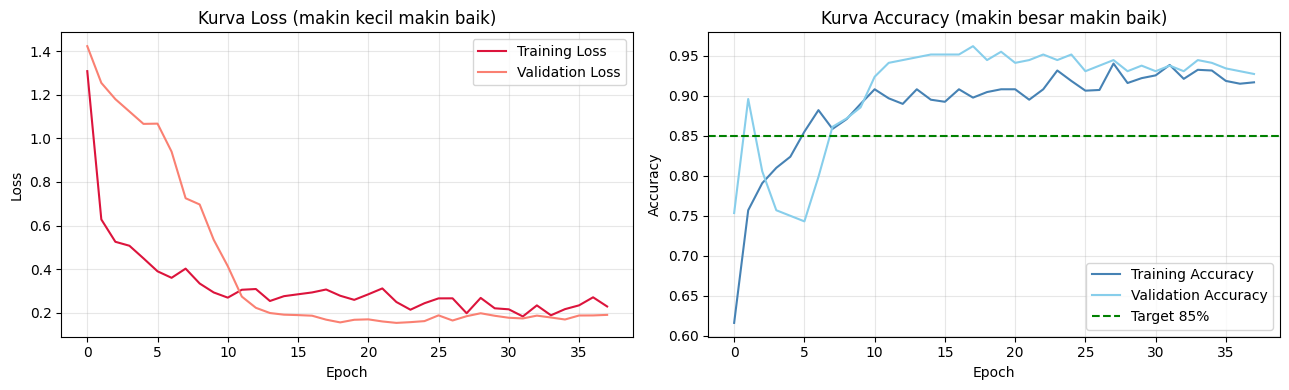

Grafik disimpan → saved_model/training_curve.png


In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(history.history["loss"],     label="Training Loss",   color="crimson")
ax1.plot(history.history["val_loss"], label="Validation Loss", color="salmon")
ax1.set_title("Kurva Loss (makin kecil makin baik)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history["accuracy"],     label="Training Accuracy",   color="steelblue")
ax2.plot(history.history["val_accuracy"], label="Validation Accuracy", color="skyblue")
ax2.axhline(y=0.85, color="green", linestyle="--", linewidth=1.5, label="Target 85%")
ax2.set_title("Kurva Accuracy (makin besar makin baik)")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("saved_model/training_curve.png", dpi=100, bbox_inches="tight")
plt.show()
print("Grafik disimpan → saved_model/training_curve.png")

In [18]:
# ── Simpan format .keras (format utama) ──────────────────────────────────────
# Format ini menyimpan SEMUANYA dalam satu file:
# arsitektur + bobot + konfigurasi optimizer dan loss
# Ini yang dipakai saat load di FastAPI server
model.save(MODEL_PATH)
print(f"[.keras] Model disimpan  -> {MODEL_PATH}")

# ── Simpan scaler ─────────────────────────────────────────────────────────────
# WAJIB disimpan bersama model
# Scaler menyimpan nilai min & max dari data training
# Harus dipakai ulang saat inference agar normalisasi identik
joblib.dump(scaler, SCALER_PATH)
print(f"[.pkl]   Scaler disimpan -> {SCALER_PATH}")

# ── Simpan daftar nama fitur ──────────────────────────────────────────────────
# Urutan fitur HARUS sama antara training dan inference
with open(FEATURES_PATH, "w") as f:
    for nama in feat_names:
        f.write(nama + "\n") 
print(f"[.txt]   Fitur disimpan  -> {FEATURES_PATH}")

# ═════════════════════════════════════════════════════════════════════════════
# TAMBAHAN: Simpan format .json
# ═════════════════════════════════════════════════════════════════════════════

# ── Simpan arsitektur model ke .json ─────────────────────────────────────────
# to_json() menghasilkan string JSON yang berisi ARSITEKTUR model saja
# (susunan layer, jumlah neuron, fungsi aktivasi)
# TIDAK termasuk bobot yang sudah dipelajari saat training
model_json_str = model.to_json()

# Parsing ke dict dulu agar bisa diformat dengan rapi (indent=2)
model_json_dict = json.loads(model_json_str)

with open(MODEL_JSON_PATH, "w") as f:
    json.dump(model_json_dict, f, indent=2)
print(f"[.json]  Arsitektur disimpan -> {MODEL_JSON_PATH}")

# ── Simpan bobot model ke .h5 ─────────────────────────────────────────────────
# save_weights() menyimpan BOBOT saja (angka-angka yang dipelajari saat training)
# Terpisah dari arsitektur yang disimpan di .json di atas
# Untuk load ulang: butuh KEDUANYA -- .json (arsitektur) + .h5 (bobot)
model.save_weights(MODEL_WEIGHTS_PATH)
print(f"[.h5]    Bobot disimpan      -> {MODEL_WEIGHTS_PATH}")

# ── Simpan metadata model ke .json ───────────────────────────────────────────
# File ini berisi informasi tambahan tentang model:
# threshold, fitur, label, performa -- berguna untuk dokumentasi & integrasi
loss_val, accuracy_val = model.evaluate(X_test, y_test, verbose=0)

import numpy as np
from sklearn.metrics import mean_absolute_error

y_pred_proba = model.predict(X_test, verbose=0)
y_pred       = np.argmax(y_pred_proba, axis=1)
mae          = mean_absolute_error(y_test, y_pred)

metadata = {
    "nama_model"   : "MathQuest Placement Model",
    "versi"        : "1.0.0",
    "deskripsi"    : "Model untuk mendeteksi topik lemah siswa berdasarkan hasil pre-test",
    "konfigurasi"  : {
        "threshold_weak"  : THRESHOLD_WEAK,
        "max_weak_topics" : MAX_WEAK_TOPICS,
        "batas_pemula"    : BATAS_PEMULA,
        "batas_menengah"  : BATAS_MENENGAH,
    },
    "label_map"    : LABEL_MAP,
    "jumlah_fitur" : len(feat_names),
    "nama_fitur"   : feat_names,
    "performa"     : {
        "test_accuracy" : round(float(accuracy_val), 4),
        "test_mae"      : round(float(mae), 4),
        "target_accuracy_tercapai" : bool(accuracy_val >= 0.85),
        "target_mae_tercapai"      : bool(mae <= 0.02),
    },
    "file"         : {
        "model_keras"    : MODEL_PATH,
        "model_json"     : MODEL_JSON_PATH,
        "model_weights"  : MODEL_WEIGHTS_PATH,
        "scaler"         : SCALER_PATH,
        "feature_names"  : FEATURES_PATH,
    }
}

with open(MODEL_META_PATH, "w") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)
print(f"[.json]  Metadata disimpan   -> {MODEL_META_PATH}")

# ── Ringkasan semua file yang tersimpan ───────────────────────────────────────
print()
print("=" * 55)
print("SEMUA FILE TERSIMPAN DI saved_model/")
print("=" * 55)

import os
for fname in sorted(os.listdir("saved_model")):
    fpath     = os.path.join("saved_model", fname)
    size_kb   = os.path.getsize(fpath) / 1024
    size_str  = f"{size_kb/1024:.1f} MB" if size_kb > 1024 else f"{size_kb:.0f} KB"
    print(f"  {fname:<45} {size_str:>8}")

print()
print("Keterangan:")
print("  .keras  = format utama, dipakai saat load di FastAPI")
print("  .pkl    = scaler normalisasi, wajib di-load bersama model")
print("  .txt    = daftar nama fitur, urutan harus sama saat inference")
print("  _architecture.json = arsitektur model saja (tanpa bobot)")
print("  _weights.h5        = bobot model saja (tanpa arsitektur)")
print("  _metadata.json     = info model: threshold, fitur, performa")


[.keras] Model disimpan  -> saved_model/placement_model.keras
[.pkl]   Scaler disimpan -> saved_model/placement_scaler.pkl
[.txt]   Fitur disimpan  -> saved_model/feature_names.txt
[.json]  Arsitektur disimpan -> saved_model/placement_model_architecture.json
[.h5]    Bobot disimpan      -> saved_model/placement_model_weights.weights.h5
[.json]  Metadata disimpan   -> saved_model/placement_model_metadata.json

SEMUA FILE TERSIMPAN DI saved_model/
  feature_names.txt                                 0 KB
  placement_model.keras                           220 KB
  placement_model.pkl                             221 KB
  placement_model_architecture.json                17 KB
  placement_model_metadata.json                     1 KB
  placement_model_weights.weights.h5              212 KB
  placement_scaler.pkl                              1 KB
  training_curve.png                               70 KB
  training_log.csv                                  1 KB

Keterangan:
  .keras  = format utama

### Format yang disepakati:

**Input dari Backend ke AI:**
```json
[
  {"user_id": "stu_0001", "no_soal": 1, "materi": "penjumlahan", "benar_salah": 1, "waktu_pengerjaan": 12.5},
  {"user_id": "stu_0001", "no_soal": 2, "materi": "pengurangan", "benar_salah": 0, "waktu_pengerjaan": 34.2}
]
```

**Output AI ke Backend:**
```json
[
  {
    "user_id"     : "stu_0001",
    "weak_topics" : ["pengurangan", "perkalian"],
    "confidence"  : 0.87
  }
]
```



In [19]:
# ── Load model dari .keras (cara utama) ──────────────────────────────────────
# Ini yang dipakai di FastAPI server
# Satu file sudah berisi arsitektur + bobot + konfigurasi
model_loaded = keras.models.load_model(
    MODEL_PATH,
    custom_objects={
        "TopicAttentionLayer"     : TopicAttentionLayer,
        "WeightedCrossEntropyLoss": WeightedCrossEntropyLoss,
    }
)
print("OK Model (.keras) berhasil di-load")

# ── Load scaler ───────────────────────────────────────────────────────────────
scaler_loaded = joblib.load(SCALER_PATH)
print("OK Scaler berhasil di-load")

# ── Load daftar nama fitur ────────────────────────────────────────────────────
feat_names_loaded = open(FEATURES_PATH).read().splitlines()
print(f"OK Feature names berhasil di-load ({len(feat_names_loaded)} fitur)")

# ═════════════════════════════════════════════════════════════════════════════
# TAMBAHAN: Load dari format .json + .h5
# ═════════════════════════════════════════════════════════════════════════════
# Cara alternatif jika ingin load dari file .json (arsitektur) + .h5 (bobot)
# Hasilnya IDENTIK dengan load dari .keras di atas

# Langkah 1: Baca arsitektur dari file .json
with open(MODEL_JSON_PATH, "r") as f:
    model_json_str = json.dumps(json.load(f))

# Langkah 2: Rekonstruksi model dari arsitektur
# model_from_json = buat ulang model hanya dari definisi arsitekturnya
# Belum ada bobotnya -- bobot masih acak di tahap ini
model_from_json = keras.models.model_from_json(
    model_json_str,
    custom_objects={
        "TopicAttentionLayer"     : TopicAttentionLayer,
        "WeightedCrossEntropyLoss": WeightedCrossEntropyLoss,
    }
)

# Langkah 3: Isi bobot dari file .h5
# load_weights = masukkan bobot yang sudah dipelajari ke model
# Setelah ini model_from_json identik dengan model_loaded di atas
model_from_json.load_weights(MODEL_WEIGHTS_PATH)

print()
print("OK Model dari .json + .h5 berhasil di-load")

# Verifikasi: prediksi keduanya harus menghasilkan output yang sama
import numpy as np
sample = X_test[:1]   # ambil satu data sample
pred_keras = model_loaded.predict(sample,     verbose=0)
pred_json  = model_from_json.predict(sample,  verbose=0)

selisih = np.abs(pred_keras - pred_json).max()
print(f"   Selisih prediksi .keras vs .json: {selisih:.8f}")
if selisih < 1e-5:
    print("   OK Keduanya menghasilkan prediksi yang identik")
else:
    print("   PERINGATAN: Ada perbedaan prediksi -- periksa ulang")

# ── Baca metadata model ───────────────────────────────────────────────────────
with open(MODEL_META_PATH, "r") as f:
    metadata_loaded = json.load(f)

print()
print("Metadata model:")
print(f"  Nama          : {metadata_loaded['nama_model']}")
print(f"  Versi         : {metadata_loaded['versi']}")
print(f"  Jumlah fitur  : {metadata_loaded['jumlah_fitur']}")
print(f"  Test accuracy : {metadata_loaded['performa']['test_accuracy']}")
print(f"  Test MAE      : {metadata_loaded['performa']['test_mae']}")
print(f"  Target acc OK : {metadata_loaded['performa']['target_accuracy_tercapai']}")
print(f"  Target MAE OK : {metadata_loaded['performa']['target_mae_tercapai']}")
print(f"  Threshold weak: {metadata_loaded['konfigurasi']['threshold_weak']}")



OK Model (.keras) berhasil di-load
OK Scaler berhasil di-load
OK Feature names berhasil di-load (20 fitur)


c:\Users\Acer\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\layer.py:421: UserWarning: `build()` was called on layer 'topic_attention', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(



OK Model dari .json + .h5 berhasil di-load
   Selisih prediksi .keras vs .json: 0.00000000
   OK Keduanya menghasilkan prediksi yang identik

Metadata model:
  Nama          : MathQuest Placement Model
  Versi         : 1.0.0
  Jumlah fitur  : 20
  Test accuracy : 0.9278
  Test MAE      : 0.0722
  Target acc OK : True
  Target MAE OK : False
  Threshold weak: 0.6


In [20]:
def predict_placement_batch(data_pretest: list, model, scaler, feat_names) -> list:
    df_input = pd.DataFrame(data_pretest)

    akurasi_per_materi = (
        df_input.groupby(["user_id", "materi"])["benar_salah"]
        .mean()
        .unstack(fill_value=0) 
    )

    akurasi_raw = akurasi_per_materi.copy()

    akurasi_per_materi.columns = [f"akurasi_{m}" for m in akurasi_per_materi.columns]

    avg_waktu_per_materi = (
        df_input.groupby(["user_id", "materi"])["waktu_pengerjaan"]
        .mean()
        .unstack(fill_value=0)
    )
    avg_waktu_per_materi.columns = [f"avg_waktu_{m}" for m in avg_waktu_per_materi.columns]

    df_siswa = akurasi_per_materi.merge(avg_waktu_per_materi, on="user_id", how="inner")

    df_siswa = df_siswa.reindex(columns=feat_names, fill_value=0)

    user_ids_input = df_siswa.index.tolist()

    X_input = scaler.transform(df_siswa.values)

    proba_semua = model.predict(X_input, verbose=0)

    hasil = []
    for i, user_id in enumerate(user_ids_input):

        proba       = proba_semua[i]
        level_index = int(np.argmax(proba))
        confidence  = float(proba[level_index])

        if user_id in akurasi_raw.index:
            akurasi_siswa = akurasi_raw.loc[user_id] 

            topik_lemah = akurasi_siswa[akurasi_siswa < THRESHOLD_WEAK]

            topik_lemah = topik_lemah.sort_values(ascending=True)

            if MAX_WEAK_TOPICS is not None:
                topik_lemah = topik_lemah.head(MAX_WEAK_TOPICS)

            weak_topics = topik_lemah.index.tolist()
        else:
            weak_topics = []

        hasil.append({
            "user_id"    : user_id,
            "weak_topics": weak_topics, 
            "confidence" : round(confidence, 4),  
        })

    return hasil


In [21]:
contoh_request = [
    {"user_id": "stu_A", "no_soal": 1, "materi": "penjumlahan",  "benar_salah": 0, "waktu_pengerjaan": 55.0},
    {"user_id": "stu_A", "no_soal": 2, "materi": "pengurangan",  "benar_salah": 0, "waktu_pengerjaan": 62.0},
    {"user_id": "stu_A", "no_soal": 3, "materi": "perkalian",    "benar_salah": 1, "waktu_pengerjaan": 48.0},
    {"user_id": "stu_A", "no_soal": 4, "materi": "penjumlahan",  "benar_salah": 0, "waktu_pengerjaan": 70.0},
    {"user_id": "stu_A", "no_soal": 5, "materi": "pembagian",    "benar_salah": 0, "waktu_pengerjaan": 80.0},

    {"user_id": "stu_B", "no_soal": 1, "materi": "penjumlahan",  "benar_salah": 1, "waktu_pengerjaan": 8.0},
    {"user_id": "stu_B", "no_soal": 2, "materi": "pengurangan",  "benar_salah": 1, "waktu_pengerjaan": 9.0},
    {"user_id": "stu_B", "no_soal": 3, "materi": "perkalian",    "benar_salah": 1, "waktu_pengerjaan": 7.5},
    {"user_id": "stu_B", "no_soal": 4, "materi": "aljabar",      "benar_salah": 0, "waktu_pengerjaan": 12.0},
    {"user_id": "stu_B", "no_soal": 5, "materi": "geometri",     "benar_salah": 1, "waktu_pengerjaan": 11.0},
]

hasil_prediksi = predict_placement_batch(
    contoh_request, model_loaded, scaler_loaded, feat_names_loaded
)

print("=" * 55)
print("HASIL PREDIKSI PLACEMENT")
print("=" * 55)
for hasil in hasil_prediksi:
    print(f"\nuser_id     : {hasil['user_id']}")
    print(f"weak_topics : {hasil['weak_topics']}")
    print(f"confidence  : {hasil['confidence']*100:.1f}%")
    if hasil['weak_topics']:
        print(f"  -> Full-Stack: cari modul ID untuk topik {hasil['weak_topics']}")
    else:
        print(f"  -> Tidak ada topik lemah yang terdeteksi (akurasi semua >= {THRESHOLD_WEAK})")

print("\n" + "=" * 55)
print("FORMAT JSON YANG DIKIRIM KE BACKEND:")
print("=" * 55)
print(json.dumps(hasil_prediksi, indent=2, ensure_ascii=False))


HASIL PREDIKSI PLACEMENT

user_id     : stu_A
weak_topics : ['aljabar', 'geometri', 'pembagian']
confidence  : 100.0%
  -> Full-Stack: cari modul ID untuk topik ['aljabar', 'geometri', 'pembagian']

user_id     : stu_B
weak_topics : ['aljabar', 'pembagian']
confidence  : 72.5%
  -> Full-Stack: cari modul ID untuk topik ['aljabar', 'pembagian']

FORMAT JSON YANG DIKIRIM KE BACKEND:
[
  {
    "user_id": "stu_A",
    "weak_topics": [
      "aljabar",
      "geometri",
      "pembagian"
    ],
    "confidence": 0.9999
  },
  {
    "user_id": "stu_B",
    "weak_topics": [
      "aljabar",
      "pembagian"
    ],
    "confidence": 0.7253
  }
]
